# Final Project: Student Performance Analysis

## Student: Guillermo Jurado

This notebook explores the `Student_performance_data.csv` dataset and investigates the following project questions:

- Which feature has the biggest impact on `GradeClass`?
- Which feature has the least impact on `GradeClass`?
- Does participating in `Music` appear to help more than `Sports`?

The main features of interest are:

- `ParentalEducation`
- `StudyTimeWeekly`
- `Absences`
- `Tutoring`
- `Music`
- `Sports`


## 1. Imports

If a package import fails, install it in your notebook environment first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

In [2]:
df = pd.read_csv("Student_performance_data.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
print("Rows, columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Rows, columns: (2392, 15)

Columns:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


## 3. Basic Data Inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [5]:
missing_values = df.isnull().sum()
missing_values

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

## 4. Summary Statistics for Features of Interest

In [6]:
features_of_interest = [
    "ParentalEducation",
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "Music",
    "Sports",
    "GradeClass"
]

summary_table = pd.DataFrame({
    "mean": df[features_of_interest].mean(),
    "median": df[features_of_interest].median(),
    "mode": df[features_of_interest].mode().iloc[0],
    "variance": df[features_of_interest].var(),
    "std_dev": df[features_of_interest].std()
})

summary_table

,mean,median,mode,variance,std_dev
ParentalEducation,1.746237,2.000000,2.000000,1.000822,1.000411
StudyTimeWeekly,9.771992,9.705363,0.001057,31.953857,5.652774
Absences,14.541388,15.000000,13.000000,71.697157,8.467417
Tutoring,0.301421,0.000000,0.000000,0.210655,0.458971
Music,0.196906,0.000000,0.000000,0.158200,0.397744
Sports,0.303512,0.000000,0.000000,0.211481,0.459870
GradeClass,2.983696,4.000000,4.000000,1.522528,1.233908


## 5. Distributions

These plots show how the main variables are distributed and give a quick picture of what the dataset looks like before modeling.

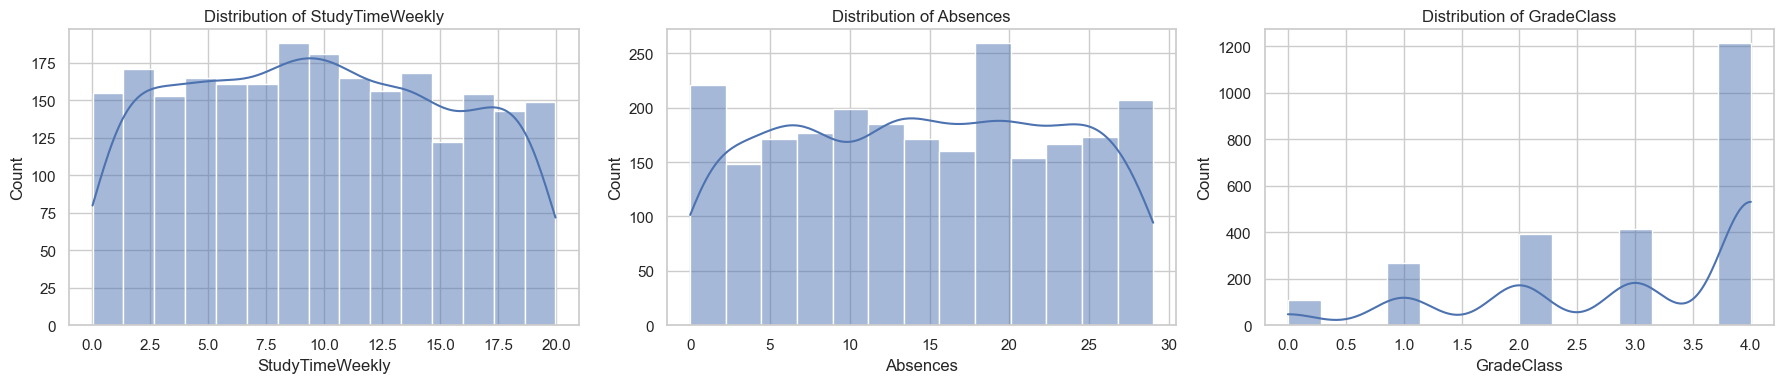

In [7]:
plot_columns = ["StudyTimeWeekly", "Absences", "GradeClass"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, plot_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()

## 6. Correlation Analysis

This checks which selected features have the strongest relationship with `GradeClass`.

Based on the current results from this dataset, `Absences` has the strongest relationship with `GradeClass` by a wide margin. The other features have much weaker relationships, although `StudyTimeWeekly` and `Tutoring` still show a small helpful trend.

In [8]:
correlations = df[features_of_interest].corr(numeric_only=True)["GradeClass"].sort_values(key=abs, ascending=False)
correlations

GradeClass           1.000000
Absences             0.728633
StudyTimeWeekly     -0.134131
Tutoring            -0.111695
ParentalEducation    0.041031
Music               -0.036065
Sports              -0.026654
Name: GradeClass, dtype: float64

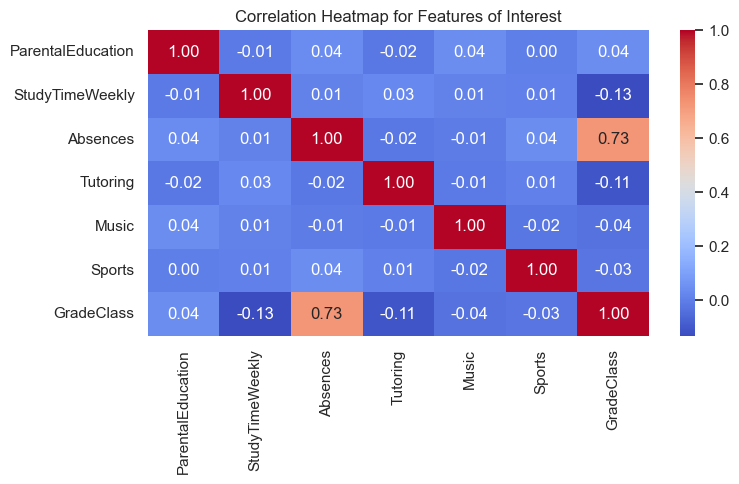

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[features_of_interest].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Features of Interest")
plt.tight_layout()

## 7. Music vs Sports

This section compares average `GradeClass` for students involved in music and sports.

In this dataset, lower `GradeClass` values correspond to better outcomes. That means a lower average in this section suggests slightly stronger performance.

In [10]:
music_comparison = df.groupby("Music")["GradeClass"].mean()
sports_comparison = df.groupby("Sports")["GradeClass"].mean()

print("Average GradeClass by Music participation:")
display(music_comparison)

print("Average GradeClass by Sports participation:")
display(sports_comparison)

Average GradeClass by Music participation:


Music
0    3.005726
1    2.893843
Name: GradeClass, dtype: float64

Average GradeClass by Sports participation:


Sports
0    3.005402
1    2.933884
Name: GradeClass, dtype: float64

In [11]:
comparison_df = pd.DataFrame({
    "Music": df.groupby("Music")["GradeClass"].mean(),
    "Sports": df.groupby("Sports")["GradeClass"].mean()
})
comparison_df

,Music,Sports
0,3.005726,3.005402
1,2.893843,2.933884


## 8. Leakage-Safe Modeling Setup

This updated modeling section excludes `StudentID`, `GPA`, and `GradeClass` from the input features. `GPA` is especially important to exclude because it is closely tied to `GradeClass` and would likely create data leakage.

The train/test split happens before model fitting, scaling, feature reduction, PCA, and model comparison.


In [12]:
selected_features = [
    "ParentalEducation",
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "Music",
    "Sports"
]

leaky_or_non_predictive = ["StudentID", "GPA", "GradeClass"]
candidate_features = [
    column for column in df.select_dtypes(include="number").columns
    if column not in leaky_or_non_predictive
]

X = df[candidate_features]
y = df["GradeClass"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Selected model features:", selected_features)
print("All non-leaky candidate features:", candidate_features)
print("Excluded to prevent leakage or ID memorization:", leaky_or_non_predictive)
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))


Selected model features: ['ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'Music', 'Sports']
All non-leaky candidate features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Excluded to prevent leakage or ID memorization: ['StudentID', 'GPA', 'GradeClass']
Train rows: 1913
Test rows: 479


## 9. Baseline Linear Regression Model

The original linear regression stays as a baseline because it is simple and interpretable. Lower `GradeClass` values mean better outcomes, so negative coefficients point toward better predicted performance.


In [13]:
linear_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

linear_model.fit(X_train[selected_features], y_train)

y_pred = linear_model.predict(X_test[selected_features])
rounded_pred = np.clip(np.rint(y_pred), 0, 4).astype(int)


In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
rounded_accuracy = accuracy_score(y_test, rounded_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")
print(f"Rounded class accuracy: {rounded_accuracy:.4%}")


MAE: 0.6125
RMSE: 0.8329
R^2: 0.5423
Rounded class accuracy: 52.6096%


In [15]:
importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": linear_model.named_steps["linearregression"].coef_
})

importance_df["AbsoluteCoefficient"] = importance_df["Coefficient"].abs()
importance_df = importance_df.sort_values("AbsoluteCoefficient", ascending=False)
importance_df


,Feature,Coefficient,AbsoluteCoefficient
2,Absences,0.898524,0.898524
1,StudyTimeWeekly,-0.176681,0.176681
3,Tutoring,-0.130611,0.130611
5,Sports,-0.071830,0.071830
4,Music,-0.031295,0.031295
0,ParentalEducation,0.012222,0.012222


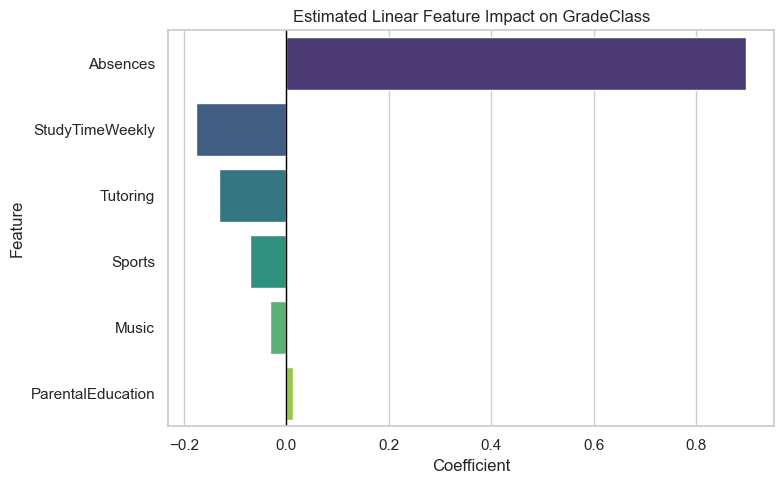

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Coefficient", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("Estimated Linear Feature Impact on GradeClass")
plt.tight_layout()


## 10. Feature Reduction, PCA, and Cross-Validated Model Comparison

This section compares the baseline against stronger alternatives:

- selected-feature linear regression
- reduced-feature linear regression using the top three training-set correlations
- PCA plus linear regression using all non-leaky numeric features
- random forest regression
- random forest classification

The reduced feature set is chosen from the training data only, which avoids using the test set during feature selection.


In [17]:
train_correlations = X_train[selected_features].join(y_train).corr(numeric_only=True)["GradeClass"].drop("GradeClass")
reduced_features = train_correlations.abs().sort_values(ascending=False).head(3).index.tolist()

print("Reduced feature set selected from training data only:", reduced_features)
display(train_correlations.sort_values(key=abs, ascending=False).to_frame("TrainCorrelationWithGradeClass"))


Reduced feature set selected from training data only: ['Absences', 'StudyTimeWeekly', 'Tutoring']


,TrainCorrelationWithGradeClass
Absences,0.729208
StudyTimeWeekly,-0.150424
Tutoring,-0.128678
ParentalEducation,0.050273
Sports,-0.036485
Music,-0.025904


In [18]:
def evaluate_regression_model(name, estimator, features):
    estimator.fit(X_train[features], y_train)
    predictions = estimator.predict(X_test[features])
    rounded = np.clip(np.rint(predictions), 0, 4).astype(int)
    return {
        "Model": name,
        "Type": "Regression",
        "Features": len(features),
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
        "Accuracy": accuracy_score(y_test, rounded)
    }


def evaluate_classifier_model(name, estimator, features):
    estimator.fit(X_train[features], y_train)
    predictions = estimator.predict(X_test[features])
    return {
        "Model": name,
        "Type": "Classifier",
        "Features": len(features),
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": np.nan,
        "Accuracy": accuracy_score(y_test, predictions)
    }


def cross_validated_score(estimator, features, model_type):
    if model_type == "Classifier":
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_validate(estimator, X[features], y, cv=cv, scoring="accuracy")
        return "CV Accuracy", scores["test_score"].mean(), scores["test_score"].std()

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(estimator, X[features], y, cv=cv, scoring="neg_mean_absolute_error")
    mae_scores = -scores["test_score"]
    return "CV MAE", mae_scores.mean(), mae_scores.std()

model_specs = [
    ("Linear selected features", make_pipeline(StandardScaler(), LinearRegression()), selected_features, "Regression"),
    ("Linear reduced top 3", make_pipeline(StandardScaler(), LinearRegression()), reduced_features, "Regression"),
    ("PCA linear all non-leaky", make_pipeline(StandardScaler(), PCA(n_components=0.95), LinearRegression()), candidate_features, "Regression"),
    ("Random forest regressor", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42), selected_features, "Regression"),
    ("Random forest classifier", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42), selected_features, "Classifier"),
    ("RF classifier all non-leaky", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42), candidate_features, "Classifier"),
]

comparison_rows = []
for name, estimator, features, model_type in model_specs:
    if model_type == "Classifier":
        row = evaluate_classifier_model(name, estimator, features)
    else:
        row = evaluate_regression_model(name, estimator, features)

    cv_metric, cv_mean, cv_std = cross_validated_score(estimator, features, model_type)
    row["CV Metric"] = cv_metric
    row["CV Mean"] = cv_mean
    row["CV Std"] = cv_std
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values(["Accuracy", "MAE"], ascending=[False, True])
comparison_df


,Model,Type,Features,MAE,RMSE,R2,Accuracy,CV Metric,CV Mean,CV Std
5,RF classifier all non-leaky,Classifier,12,0.354906,0.772708,NaN,0.724426,CV Accuracy,0.714461,0.008646
4,Random forest classifier,Classifier,6,0.405010,0.814790,NaN,0.682672,CV Accuracy,0.681018,0.010512
3,Random forest regressor,Regression,6,0.523833,0.783790,0.594638,0.632568,CV MAE,0.494391,0.022793
2,PCA linear all non-leaky,Regression,12,0.585579,0.805865,0.571483,0.565762,CV MAE,0.574772,0.021991
1,Linear reduced top 3,Regression,3,0.616526,0.836958,0.537777,0.542797,CV MAE,0.594994,0.018985
0,Linear selected features,Regression,6,0.612462,0.832873,0.542279,0.526096,CV MAE,0.591748,0.019499


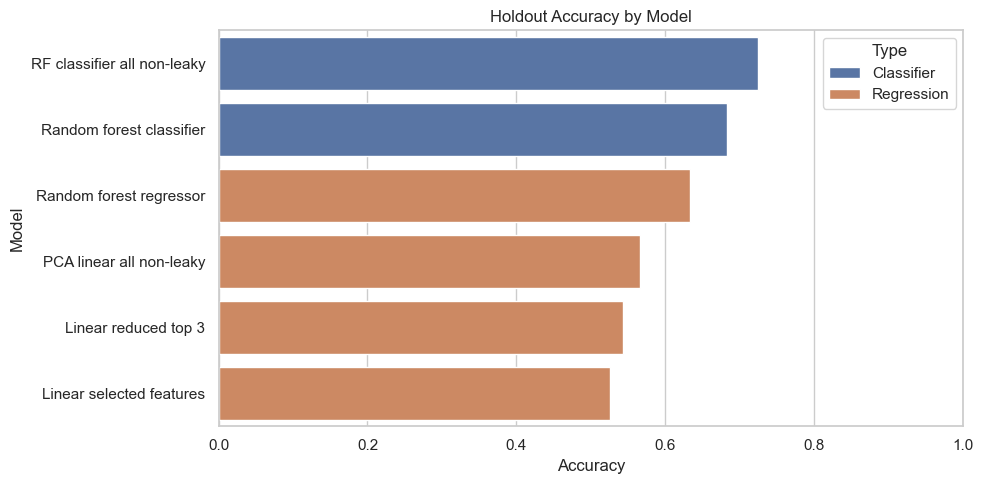

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Accuracy", y="Model", hue="Type", dodge=False)
plt.title("Holdout Accuracy by Model")
plt.xlim(0, 1)
plt.tight_layout()


## 11. Random Forest Feature Importance

Permutation importance measures how much model accuracy drops when each feature is shuffled. This gives another way to answer which features matter most.


In [20]:
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42
)
rf_classifier.fit(X_train[selected_features], y_train)

permutation = permutation_importance(
    rf_classifier,
    X_test[selected_features],
    y_test,
    n_repeats=25,
    random_state=42,
    scoring="accuracy"
)

rf_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "ImportanceMean": permutation.importances_mean,
    "ImportanceStd": permutation.importances_std
}).sort_values("ImportanceMean", ascending=False)

rf_importance_df


,Feature,ImportanceMean,ImportanceStd
2,Absences,0.339624,0.020631
1,StudyTimeWeekly,0.028727,0.012390
3,Tutoring,0.026889,0.010845
4,Music,0.001086,0.004502
5,Sports,-0.000585,0.006208
0,ParentalEducation,-0.007015,0.007831


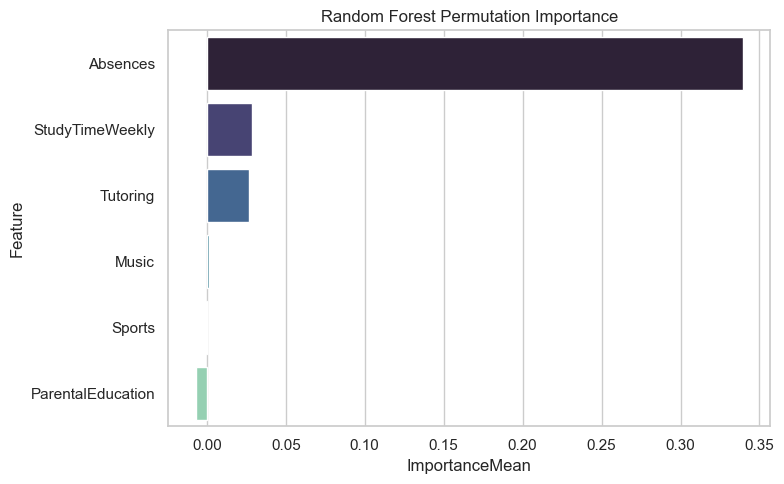

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance_df, x="ImportanceMean", y="Feature", hue="Feature", palette="mako", legend=False)
plt.title("Random Forest Permutation Importance")
plt.tight_layout()


## 12. PDP and ICE Interpretation

Partial dependence plots show the average predicted effect of a feature. ICE lines show how individual predictions change as that feature changes. This helps show whether a feature has a consistent effect across students or whether the effect varies student by student.


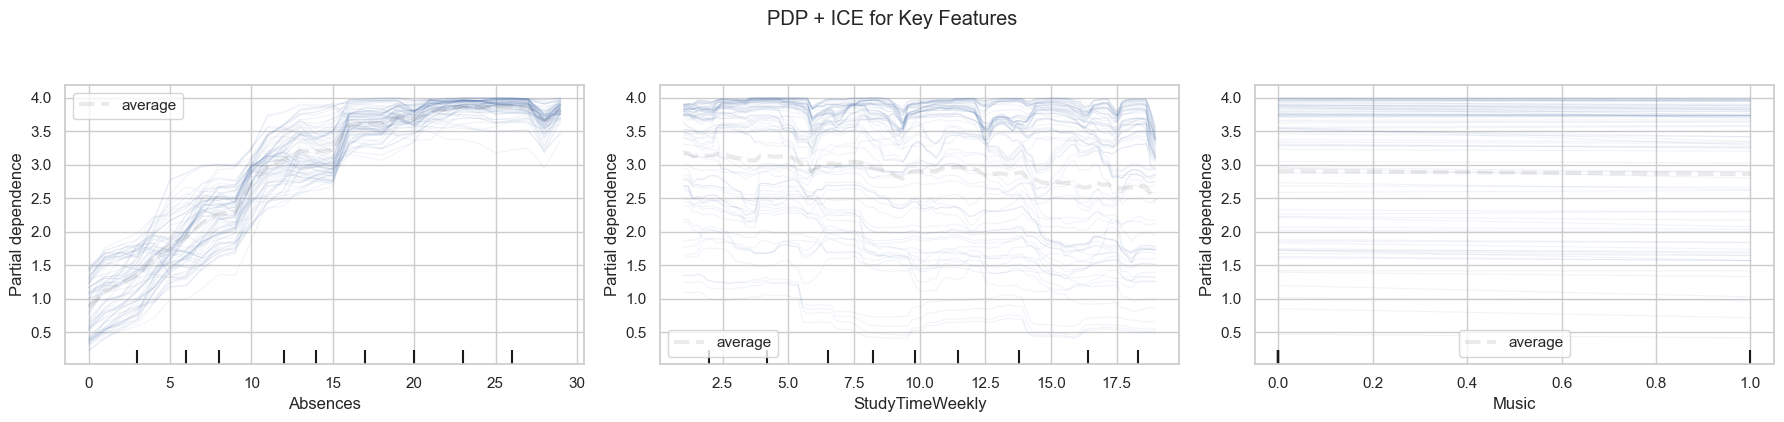

In [22]:
rf_regressor = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42
)
rf_regressor.fit(X_train[selected_features], y_train)

ice_features = ["Absences", "StudyTimeWeekly", "Music"]
X_ice = X_test[selected_features].astype(float)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
PartialDependenceDisplay.from_estimator(
    rf_regressor,
    X_ice,
    ice_features,
    kind="both",
    subsample=80,
    random_state=42,
    ax=axes,
    line_kw={"alpha": 0.08, "linewidth": 0.8},
    pd_line_kw={"color": "black", "linewidth": 3}
)
fig.suptitle("PDP + ICE for Key Features", y=1.05)
plt.tight_layout()
plt.savefig("ice_pdp_gradeclass.png", dpi=150, bbox_inches="tight")


## 13. Updated Written Takeaways

This expanded analysis strengthens the original project because it compares multiple modeling approaches instead of relying on one linear regression.

- `GPA` was excluded to prevent data leakage.
- `Absences` is the strongest and most consistent predictor across correlation, feature reduction, linear regression, and random forest importance.
- `StudyTimeWeekly` and `Tutoring` are the next most useful selected features, and both are associated with better outcomes.
- `Music` has a small positive association, but it is much weaker than absences, study time, or tutoring.
- PCA was useful as a comparison, but it is less interpretable because it blends original features into components.
- The random forest classifier gives a stronger predictive benchmark because `GradeClass` is a category rather than a truly continuous value.
- PDP and ICE plots help show how feature effects behave across individual students.
- These results show relationships in the dataset, not proof that any single factor causes better or worse grades.


## 14. Updated Presentation Notes

A few short speaking points you can use for class:

- I excluded `GPA` because it would likely leak information about `GradeClass`.
- I kept linear regression as the interpretable baseline.
- I added feature reduction to see whether fewer variables could explain most of the pattern.
- I tested PCA, but it is less useful for interpretation because it hides the original feature names.
- I added random forest models to compare against a non-linear model.
- I used cross-validation so the findings were not based only on one train/test split.
- I used PDP and ICE plots to show how key features affect predictions for both the average student and individual students.
- The clearest takeaway is still that absences matter most, while music has a smaller relationship with better outcomes.
